<a href="https://colab.research.google.com/github/NamSee04/CS114.P11/blob/main/Copy_of_CS114_P11_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np

In [ ]:
# Define the path to the .npz file
npz_path = '/content/drive/MyDrive/features_and_paths.npz'

# Load the .npz file
data = np.load(npz_path)

In [ ]:
features = data['features']
labels = data['paths']
print(labels)

['/content/drive/MyDrive/Public/Honda/22520394-22520395.Honda.216.jpg'
 '/content/drive/MyDrive/Public/Honda/22520394-22520395.Honda.204.jpg'
 '/content/drive/MyDrive/Public/Honda/22520394-22520395.Honda.207.jpg' ...
 '/content/drive/MyDrive/Public/VinFast/22520459-22520507-22520862.VinFast.9.jpg'
 '/content/drive/MyDrive/Public/VinFast/22520459-22520507-22520862.VinFast.33.jpg'
 '/content/drive/MyDrive/Public/VinFast/22520459-22520507-22520862.VinFast.24.jpg']


In [ ]:
LABEL = {
    'Others': 0,
    'Honda': 1,
    'Hyundai': 2,
    'KIA': 3,
    'Mazda': 4,
    'Mitsubishi': 5,
    'Suzuki': 6,
    'Toyota': 7,
    'VinFast': 8,
}


numerical_labels = []
for path in labels:
    brand = path.split('/')[-2]
    assert(brand in LABEL)
    numerical_labels.append(LABEL[brand])

labels = np.array(numerical_labels)

print(features.shape)
print(labels.shape)

(37785, 1280)
(37785,)


Fold 1 accuracy: 0.2608177848352521


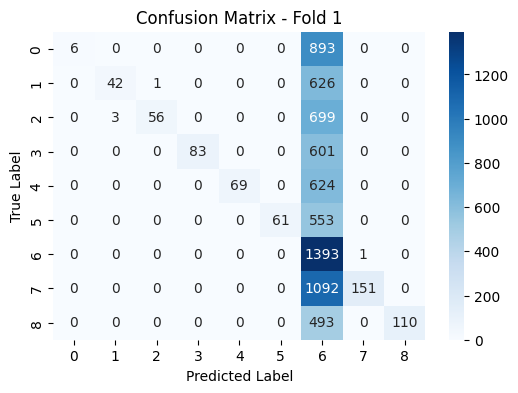

Fold 2 accuracy: 0.2530104538838163


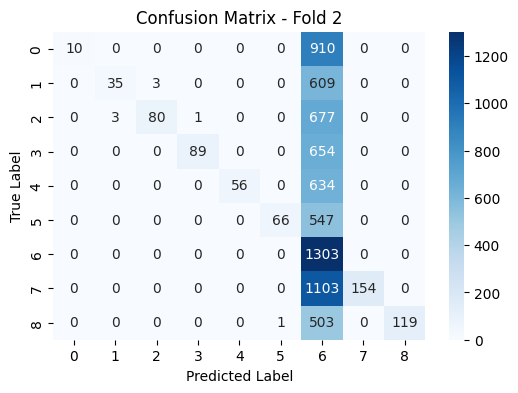

Fold 3 accuracy: 0.2638613206298796


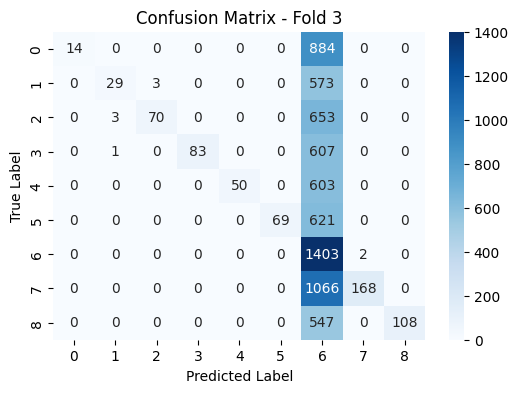

Fold 4 accuracy: 0.26134709540823076


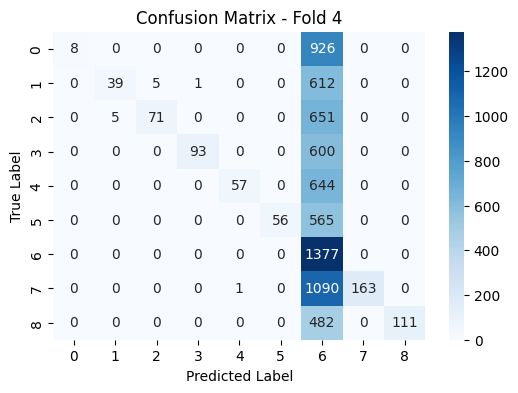

Fold 5 accuracy: 0.2642583035596136


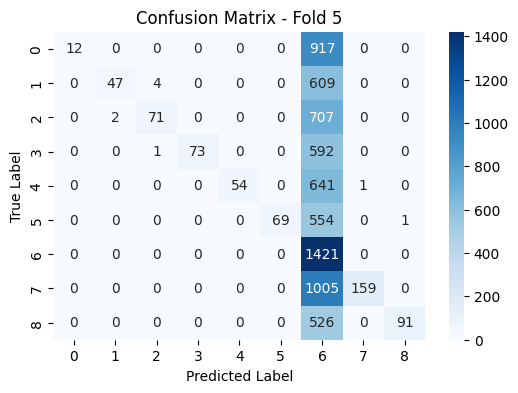

Average accuracy across 5 folds: 0.2606589916633585


In [ ]:
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

n_pca_components = 100
n_splits = 5

pca = PCA(n_components=n_pca_components)
features_pca = pca.fit_transform(features)

kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

accuracy_scores = []
confusion_matrices = []

# Iterate through the folds
for fold, (train_index, test_index) in enumerate(kf.split(features_pca), start=1):
    # Split the PCA-transformed dataset into train and test sets
    X_train, X_test = features_pca[train_index], features_pca[test_index]
    y_train, y_test = labels[train_index], labels[test_index]

    svc = SVC(kernel='rbf', gamma=0.1)
    svc.fit(X_train, y_train)


    y_pred = svc.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)
    print(f"Fold {fold} accuracy: {accuracy}")


    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(labels), yticklabels=np.unique(labels))
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


average_accuracy = np.mean(accuracy_scores)
print(f"Average accuracy across {n_splits} folds: {average_accuracy}")
